Fraud rate prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snb

In [2]:
df = pd.read_csv('Fraud.csv')

Understanding and cleaning of given dataset and performing exploratory data analysis (EDA).

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [8]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [10]:
df.groupby('type')['isFraud'].mean()

type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64

In [11]:
#df.groupby('type')['isFraud'].sum()

In [12]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['oldbalanceDest'] - df['newbalanceDest']
df['log_amount'] = np.log1p(df['amount'])
df['isMerchant'] = df['nameDest'].str.startswith('M').astype(int)

In [13]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)

In [14]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [15]:
df.head

<bound method NDFrame.head of          step      amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0           1     9839.64      170136.00       160296.36            0.00   
1           1     1864.28       21249.00        19384.72            0.00   
2           1      181.00         181.00            0.00            0.00   
3           1      181.00         181.00            0.00        21182.00   
4           1    11668.14       41554.00        29885.86            0.00   
...       ...         ...            ...             ...             ...   
6362615   743   339682.13      339682.13            0.00            0.00   
6362616   743  6311409.28     6311409.28            0.00            0.00   
6362617   743  6311409.28     6311409.28            0.00        68488.84   
6362618   743   850002.52      850002.52            0.00            0.00   
6362619   743   850002.52      850002.52            0.00      6510099.11   

         newbalanceDest  isFraud  isFlaggedFraud  balance

In [16]:
df['isOrigZeroAfter'] = (df['newbalanceOrig'] == 0).astype(int)

Performing various methods in feature engineering.

In [17]:
df['origBalanceError'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['destBalanceError'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']


In [18]:
df.shape

(6362620, 19)

In [19]:
#plt.figure(figsize=(12, 8))
#snb.heatmap(df.corr(), annot=False, cmap='coolwarm')
#plt.show()

In [20]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest,log_amount,isMerchant,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isOrigZeroAfter,origBalanceError,destBalanceError
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,9839.64,0.0,9.194276,1,False,False,True,False,0,0.0,9839.64
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,1864.28,0.0,7.531166,1,False,False,True,False,0,0.0,1864.28
2,1,181.00,181.0,0.00,0.0,0.0,1,0,181.00,0.0,5.204007,0,False,False,False,True,1,0.0,181.00
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,181.00,21182.0,5.204007,0,True,False,False,False,1,0.0,21363.00
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,11668.14,0.0,9.364703,1,False,False,True,False,0,0.0,11668.14


In [21]:
split_step = df['step'].quantile(0.8)
train = df[df['step'] < split_step]
test = df[df['step'] >= split_step]

In [22]:
print(train.shape)
print(test.shape)

(5069097, 19)
(1293523, 19)


In [23]:
X_train = train.drop('isFraud', axis=1)
y_train = train['isFraud']

X_test = test.drop('isFraud', axis=1)
y_test = test['isFraud']

y_train.value_counts()
y_test.value_counts()

In [25]:
cols_to_drop = [
    'step',
    'newbalanceOrig',
    'newbalanceDest'
]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [26]:
X_train.shape

(5069097, 15)

Now will import the respective libraries and will follow train-test strategy with using various models and methods.

First tesing Logistic Regression for analysing the dataset as per for randomness and how the models performs we will conclude and use after process to increase recalls and confusion matrices for every try.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [28]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)

In [29]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [30]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

In [31]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1238850   50415]
 [     42    4216]]


In [32]:
print("n\Classification Report:")
print(classification_report(y_test, y_pred))

n\Classification Report:


<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\vedan\AppData\Local\Temp\ipykernel_18084\1541391480.py:1: SyntaxWarning: invalid escape sequence '\C'
  print("n\Classification Report:")


              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1289265
           1       0.08      0.99      0.14      4258

    accuracy                           0.96   1293523
   macro avg       0.54      0.98      0.56   1293523
weighted avg       1.00      0.96      0.98   1293523



In [33]:
print("n\ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

n\ROC-AUC Score:


<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:1: SyntaxWarning: invalid escape sequence '\R'
C:\Users\vedan\AppData\Local\Temp\ipykernel_18084\1996053979.py:1: SyntaxWarning: invalid escape sequence '\R'
  print("n\ROC-AUC Score:")


0.9932725233099075


In [34]:
threshold = 0.47
y_pred_1 = (y_prob > threshold).astype(int)

In [35]:
print(confusion_matrix(y_test, y_pred_1))
print(classification_report(y_test, y_pred_1))

[[1234127   55138]
 [     38    4220]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1289265
           1       0.07      0.99      0.13      4258

    accuracy                           0.96   1293523
   macro avg       0.54      0.97      0.56   1293523
weighted avg       1.00      0.96      0.98   1293523



In [36]:
for threshold in [0.5, 0.3, 0.2, 0.1, 0.05]:
    y_pred_custom = (y_prob > threshold).astype(int)
    print("\nThreshold:", threshold)
    print(classification_report(y_test, y_pred_custom))



Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1289265
           1       0.08      0.99      0.14      4258

    accuracy                           0.96   1293523
   macro avg       0.54      0.98      0.56   1293523
weighted avg       1.00      0.96      0.98   1293523


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.93      0.96   1289265
           1       0.05      0.99      0.09      4258

    accuracy                           0.93   1293523
   macro avg       0.52      0.96      0.53   1293523
weighted avg       1.00      0.93      0.96   1293523


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1289265
           1       0.03      1.00      0.07      4258

    accuracy                           0.91   1293523
   macro avg       0.52      0.95      0.51   1293523
weighted avg       1.00   

In [37]:
from sklearn.metrics import f1_score

best_f1 = 0
best_threshold = 0

for threshold in np.arange(0.01, 0.5, 0.01):
    y_pred_custom = (y_prob > threshold).astype(int)
    f1 = f1_score(y_test, y_pred_custom)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)


Best Threshold: 0.49
Best F1: 0.1395749188902867


In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)



In [40]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]


In [44]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_rf))


Confusion Matrix:
[[1289265       0]
 [      2    4256]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289265
           1       1.00      1.00      1.00      4258

    accuracy                           1.00   1293523
   macro avg       1.00      1.00      1.00   1293523
weighted avg       1.00      1.00      1.00   1293523


ROC-AUC Score:
1.0


In [45]:
print(X_train.columns)

Index(['amount', 'oldbalanceOrg', 'oldbalanceDest', 'isFlaggedFraud',
       'balanceDiffOrig', 'balanceDiffDest', 'log_amount', 'isMerchant',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
       'isOrigZeroAfter', 'origBalanceError', 'destBalanceError'],
      dtype='str')


In [46]:
X_train = X_train.drop('isFlaggedFraud', axis=1)
X_test = X_test.drop('isFlaggedFraud', axis=1)

In [47]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [49]:
X_train.columns

Index(['amount', 'oldbalanceOrg', 'oldbalanceDest', 'balanceDiffOrig',
       'balanceDiffDest', 'log_amount', 'isMerchant', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'isOrigZeroAfter',
       'origBalanceError', 'destBalanceError'],
      dtype='str')

In [50]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:
[[1289265       0]
 [      2    4256]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289265
           1       1.00      1.00      1.00      4258

    accuracy                           1.00   1293523
   macro avg       1.00      1.00      1.00   1293523
weighted avg       1.00      1.00      1.00   1293523


ROC-AUC Score:
0.9999999976319248


In [51]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

In [52]:
importance.sort_values(ascending=False).head(10)

origBalanceError    0.321097
balanceDiffOrig     0.190069
isOrigZeroAfter     0.127659
oldbalanceOrg       0.101969
amount              0.059675
type_PAYMENT        0.044061
log_amount          0.033389
isMerchant          0.031038
type_TRANSFER       0.024441
balanceDiffDest     0.022142
dtype: float64

In [53]:
drop_cols = ['origBalanceError', 'balanceDiffOrig', 'isOrigZeroAfter']

X_train_reduced = X_train.drop(columns=drop_cols)
X_test_reduced = X_test.drop(columns=drop_cols)


In [54]:
rf2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train_reduced, y_train)

y_pred_rf2 = rf2.predict(X_test_reduced)
y_prob_rf2 = rf2.predict_proba(X_test_reduced)[:,1]

In [55]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf2))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_rf2))

Confusion Matrix:
[[1289255      10]
 [   1100    3158]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289265
           1       1.00      0.74      0.85      4258

    accuracy                           1.00   1293523
   macro avg       1.00      0.87      0.93   1293523
weighted avg       1.00      1.00      1.00   1293523


ROC-AUC Score:
0.9815379532051822


In [56]:
!pip install xgboost

In [57]:
neg = y_train.value_counts()[0]
pos = y_train.value_counts()[1]

In [58]:
scale_pos_weight = neg/pos
print(scale_pos_weight)

1280.6932996207333


In [59]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_job=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [60]:
xgb.fit(X_train, y_train)

A:\Programming\DS\Fraud Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:13:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_job", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [61]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [62]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_xgb))

Confusion Matrix:
[[1289255      10]
 [      2    4256]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289265
           1       1.00      1.00      1.00      4258

    accuracy                           1.00   1293523
   macro avg       1.00      1.00      1.00   1293523
weighted avg       1.00      1.00      1.00   1293523


ROC-AUC Score:
0.9999989356412464


In [63]:
!pip install shap

In [ ]:
Here the SHAP plot shows the origin-side balance over inconsistencies dominate.

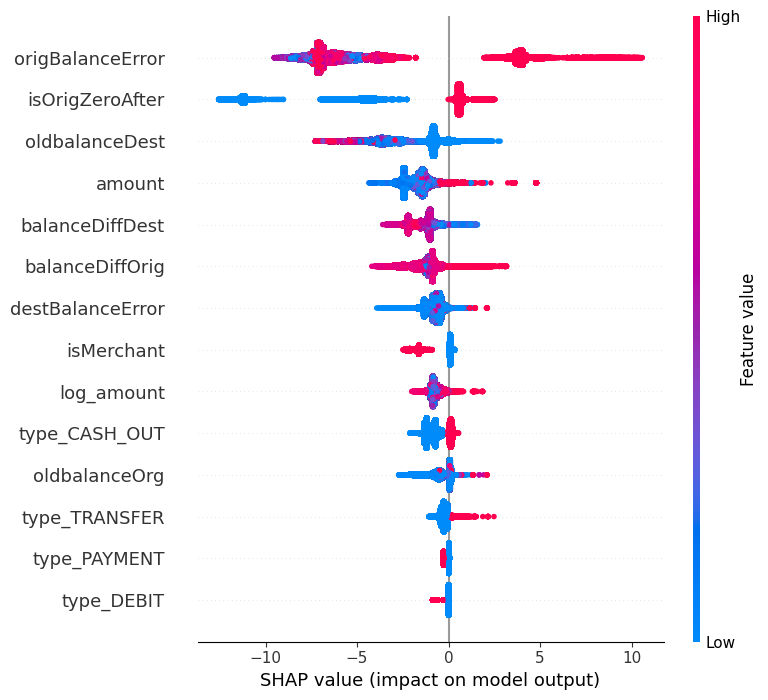

In [66]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


Here SHAP analysis indicates that fraud predictions are primarily driven by origin-side balance inconsistencies (origBalanceError), large balance differences (balanceDiffOrig), and transactions resulting in zero post-transaction balance (isOrigZeroAfter). These features align with the dataset description that fraudulent agents attempt to empty accounts.

Now the prevension strategies should be:
- Real-time fraud scoring system
- Replace static rule with dynamic ML threshold
- Risk-based 2FA 
- Temporary freeze for high-risk accounts
- Continuous retraining pipeline
- Fraud monitoring dashboard

The infrastructure of the following model could be updated as:
- Reduction in fraud losses
- Change in false positive rate
- A/B testing old vs new system
- Model drift monitoring
- Customer complaint analysis

So we can conclude here:
- ML model successfully captures fraud patterns
- Feature engineering was key
- Model aligns with business logic
- Deployment strategy proposed